# 01 — EDA & Demand Analysis
Ride-hailing marketplace data · Berlin zones

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

In [5]:
df = pd.read_csv('sample_rides.csv', parse_dates=['timestamp'])
print(f'Rows: {len(df):,} | Cols: {df.shape[1]}')
df.head()

Rows: 1,000 | Cols: 17


,timestamp,week,hour,weekday,is_weekend,zone,demand_score,supply_score,demand_supply_ratio,surge_multiplier,base_price_eur,final_price_eur,voucher_applied,voucher_discount_eur,post_period,conversion,ride_duration_min
0,2024-01-01 10:00:00,1,10,0,0,Neukölln,1.455,4.673,0.311,1.042,6.01,6.26,0,0.0,0,1,20.0
1,2024-01-01 10:55:00,1,10,0,0,Neukölln,1.686,4.580,0.368,1.025,4.96,5.09,0,0.0,0,1,25.8
2,2024-01-01 11:55:00,1,11,0,0,Prenzlauer Berg,1.168,6.012,0.194,1.027,8.68,8.91,0,0.0,0,1,10.0
3,2024-01-01 15:00:00,1,15,0,0,Prenzlauer Berg,1.068,4.798,0.223,1.000,11.75,11.75,0,0.0,0,1,13.0
4,2024-01-01 19:51:00,1,19,0,0,Prenzlauer Berg,3.860,3.839,1.005,1.048,7.02,7.36,0,0.0,0,0,20.2


In [6]:
df.describe().round(3)

,timestamp,week,hour,weekday,is_weekend,demand_score,supply_score,demand_supply_ratio,surge_multiplier,base_price_eur,final_price_eur,voucher_applied,voucher_discount_eur,post_period,conversion,ride_duration_min
count,1000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,2024-02-14 02:56:45.120000,6.748,11.631,2.927,0.256,1.595,5.043,0.353,1.017,7.958,8.098,0.174,0.438,0.523,0.703,15.927
min,2024-01-01 10:00:00,1.000,0.000,0.000,0.000,0.009,3.030,0.002,1.000,4.000,4.000,0.000,0.000,0.000,0.000,3.100
25%,2024-01-22 05:41:30,3.750,6.000,1.000,0.000,0.501,4.608,0.092,1.000,5.962,6.018,0.000,0.000,0.000,0.000,11.500
50%,2024-02-14 17:06:00,7.000,12.000,3.000,0.000,1.202,5.002,0.235,1.001,7.885,8.080,0.000,0.000,1.000,1.000,15.000
75%,2024-03-07 23:43:15,10.000,17.000,5.000,1.000,2.216,5.452,0.474,1.028,9.942,10.072,0.000,0.000,1.000,1.000,19.200
max,2024-03-30 23:23:00,12.000,23.000,6.000,1.000,7.141,8.087,2.317,1.400,11.980,13.450,1.000,3.460,1.000,1.000,45.000
std,NaN,3.650,6.711,1.954,0.437,1.368,0.743,0.355,0.028,2.296,2.353,0.379,0.982,0.500,0.457,6.171


## Demand & surge by hour

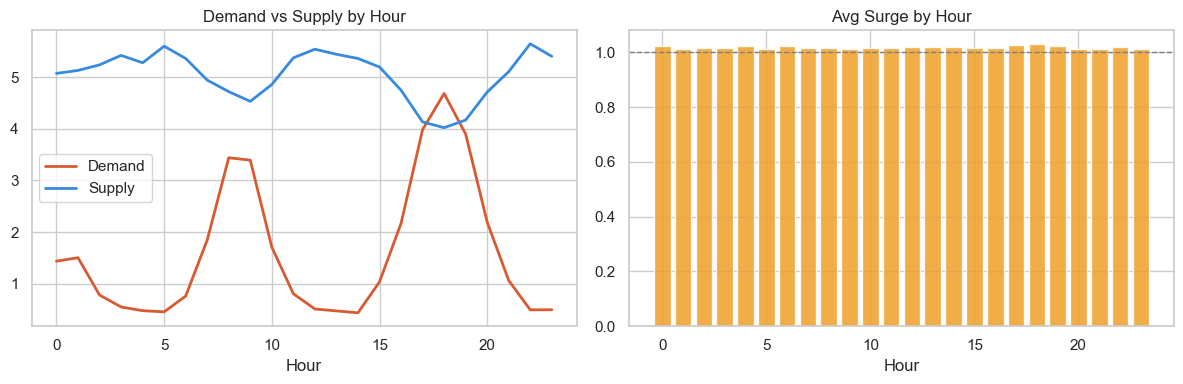

In [7]:
hourly = df.groupby('hour').agg(
    demand=('demand_score','mean'),
    supply=('supply_score','mean'),
    surge=('surge_multiplier','mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hourly['hour'], hourly['demand'], label='Demand', lw=2, color='#D85A30')
axes[0].plot(hourly['hour'], hourly['supply'], label='Supply',  lw=2, color='#378ADD')
axes[0].set(title='Demand vs Supply by Hour', xlabel='Hour')
axes[0].legend()
axes[1].bar(hourly['hour'], hourly['surge'], color='#EF9F27', alpha=0.85)
axes[1].axhline(1.0, color='gray', ls='--', lw=1)
axes[1].set(title='Avg Surge by Hour', xlabel='Hour')
plt.tight_layout()
plt.show()

## Weekday patterns

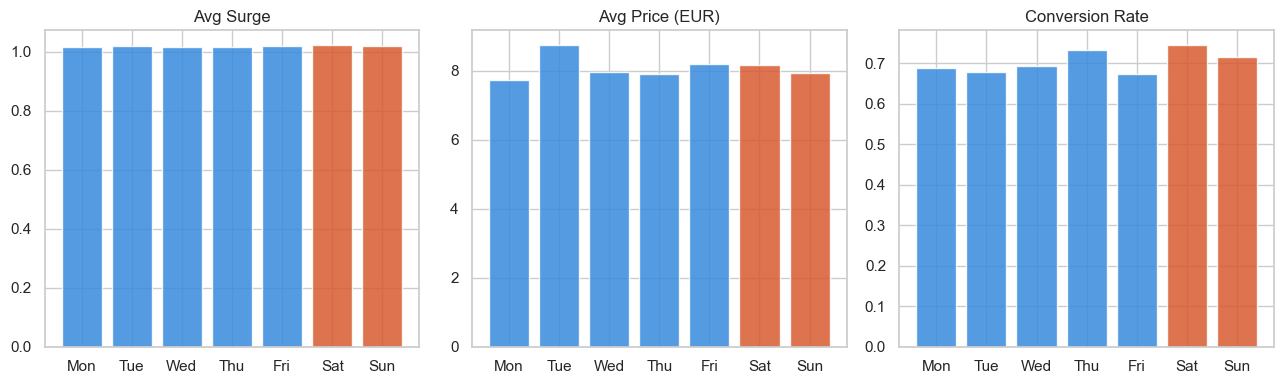

In [8]:
day_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
daily = df.groupby('weekday').agg(
    surge=('surge_multiplier','mean'),
    price=('final_price_eur','mean'),
    conv=('conversion','mean')
).reset_index()
daily['day'] = daily['weekday'].map(day_map)
colors = ['#378ADD']*5 + ['#D85A30']*2

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes, ['surge','price','conv'], ['Avg Surge','Avg Price (EUR)','Conversion Rate']):
    ax.bar(daily['day'], daily[col], color=colors, alpha=0.85)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Zone analysis

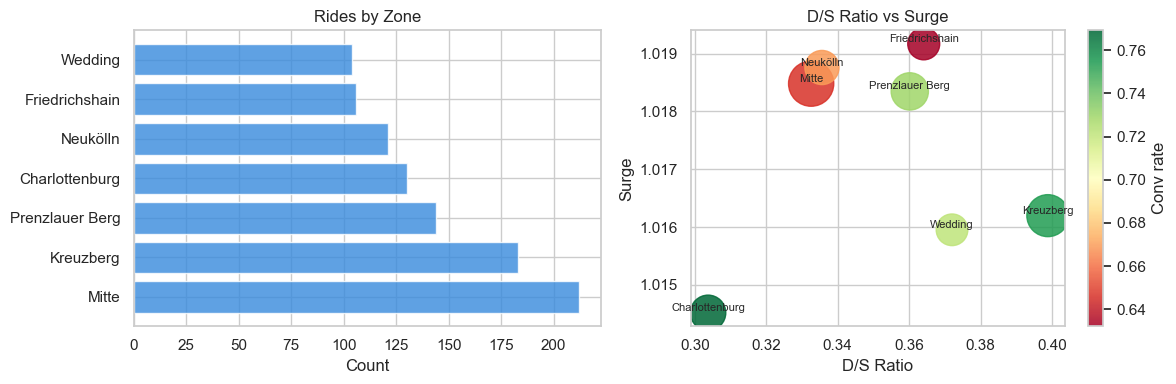

           zone  rides  surge  conv    ds
          Mitte    212  1.018 0.646 0.333
      Kreuzberg    183  1.016 0.754 0.399
Prenzlauer Berg    144  1.018 0.729 0.360
 Charlottenburg    130  1.015 0.769 0.304
       Neukölln    121  1.019 0.669 0.336
 Friedrichshain    106  1.019 0.632 0.364
        Wedding    104  1.016 0.721 0.372


In [9]:
zone = df.groupby('zone').agg(
    rides=('conversion','count'),
    surge=('surge_multiplier','mean'),
    conv=('conversion','mean'),
    ds=('demand_supply_ratio','mean')
).sort_values('rides', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(zone['zone'], zone['rides'], color='#378ADD', alpha=0.8)
axes[0].set(title='Rides by Zone', xlabel='Count')
sc = axes[1].scatter(zone['ds'], zone['surge'], s=zone['rides']*5,
    c=zone['conv'], cmap='RdYlGn', alpha=0.85)
plt.colorbar(sc, ax=axes[1], label='Conv rate')
for _, r in zone.iterrows():
    axes[1].annotate(r['zone'], (r['ds'], r['surge']), fontsize=8, ha='center', va='bottom')
axes[1].set(title='D/S Ratio vs Surge', xlabel='D/S Ratio', ylabel='Surge')
plt.tight_layout()
plt.show()
print(zone.round(3).to_string(index=False))

## Price elasticity

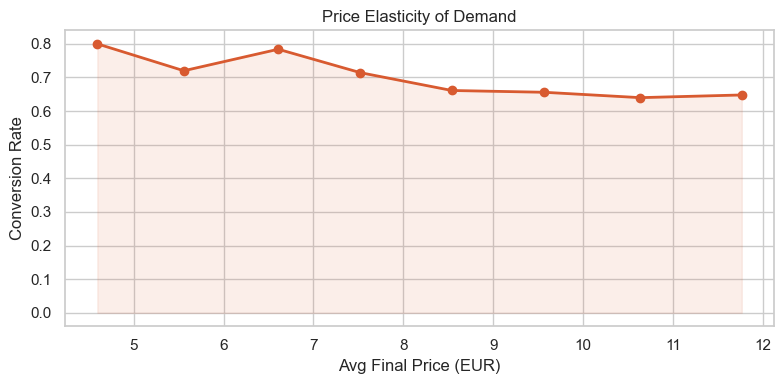

Price elasticity coefficient: -0.244


In [11]:
df['price_bin'] = pd.qcut(df['final_price_eur'], q=8, duplicates='drop')
elast = df.groupby('price_bin', observed=True).agg(
    conv=('conversion','mean'),
    price=('final_price_eur','mean')
).reset_index()

plt.figure(figsize=(8, 4))
plt.plot(elast['price'], elast['conv'], marker='o', lw=2, color='#D85A30')
plt.fill_between(elast['price'], elast['conv'], alpha=0.1, color='#D85A30')
plt.title('Price Elasticity of Demand')
plt.xlabel('Avg Final Price (EUR)')
plt.ylabel('Conversion Rate')
plt.tight_layout()
plt.show()

d_conv  = elast['conv'].iloc[-1]  - elast['conv'].iloc[0]
d_price = elast['price'].iloc[-1] - elast['price'].iloc[0]
coef = (d_conv/elast['conv'].mean()) / (d_price/elast['price'].mean())
print(f'Price elasticity coefficient: {coef:.3f}')